<h2>Correlaciones</h2>

In [2]:
load('.RData')

In [112]:
library('corrplot')
library(tidyverse)
library(ggpubr)

In [7]:
#Se van a utilizar el dataset sin NA
head(df)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007
Adelie,Torgersen,38.9,17.8,181,3625,female,2007


Vamos a comparar las correlaciones por especie
<br>
<h4>1. Adelie</h4>

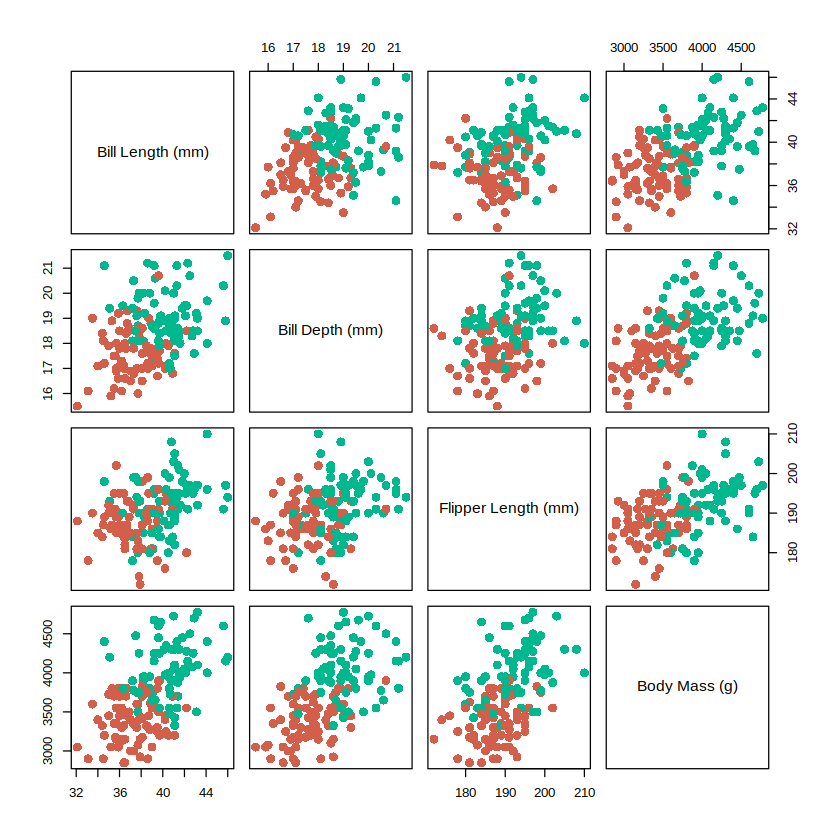

In [38]:
pairs(df[df$species == 'Adelie', 3:6], 
      cex=1.5, 
      labels = c('Bill Length (mm)', 'Bill Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)'), 
      pch=16, 
      col = sex_color[df$sex])

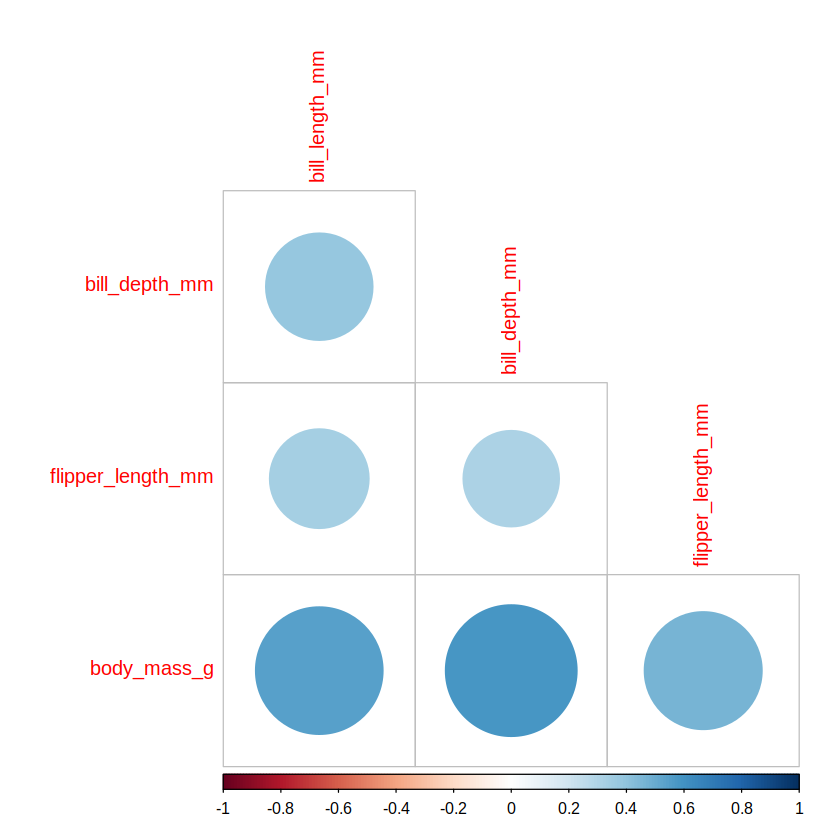

In [44]:
df_adelie.cor <- cor(df[df$species == 'Adelie', 3:6])
df_adelie.test <- cor.mtest(df[df$species == 'Adelie', 3:6])
adelie.corrplot <- corrplot(df_adelie.cor, p.mat = df_adelie.test$p, insig = 'blank', type = 'lower', diag = FALSE)


<h4>2. Chinstrap</h4>

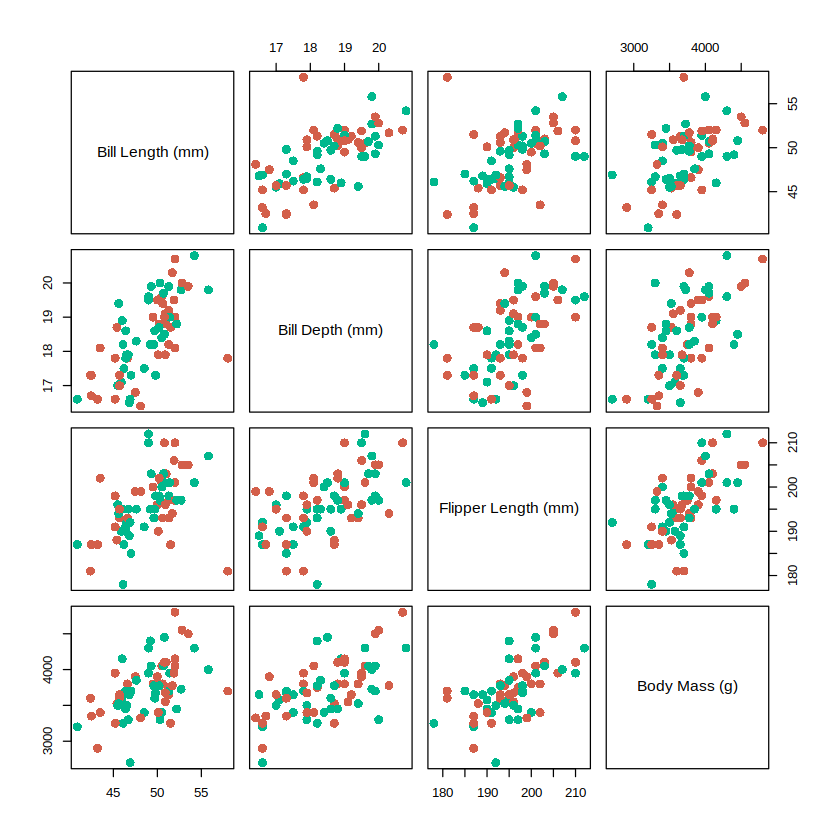

In [40]:
pairs(df[df$species == 'Chinstrap', 3:6], 
      cex=1.5, 
      labels = c('Bill Length (mm)', 'Bill Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)'), 
      pch=16, 
      col = sex_color[df$sex])

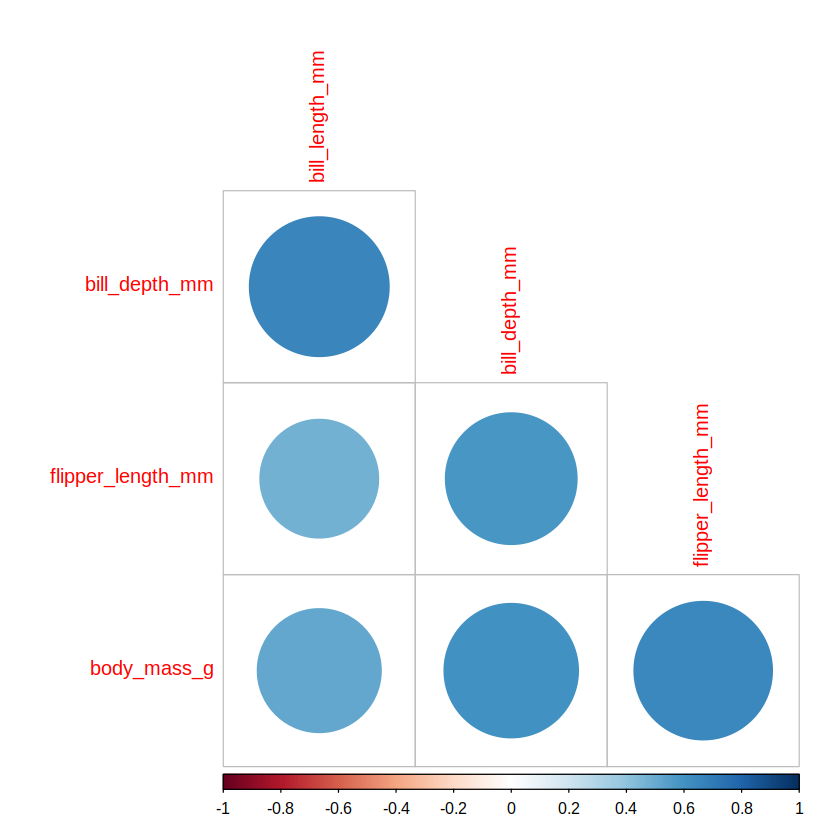

In [45]:
df_adelie.cor <- cor(df[df$species == 'Chinstrap', 3:6])
df_adelie.test <- cor.mtest(df[df$species == 'Chinstrap', 3:6])
chinstrap.corrplot <- corrplot(df_adelie.cor, p.mat = df_adelie.test$p, insig = 'blank', type = 'lower', diag = FALSE)

<h4>2. Gentoo</h4>

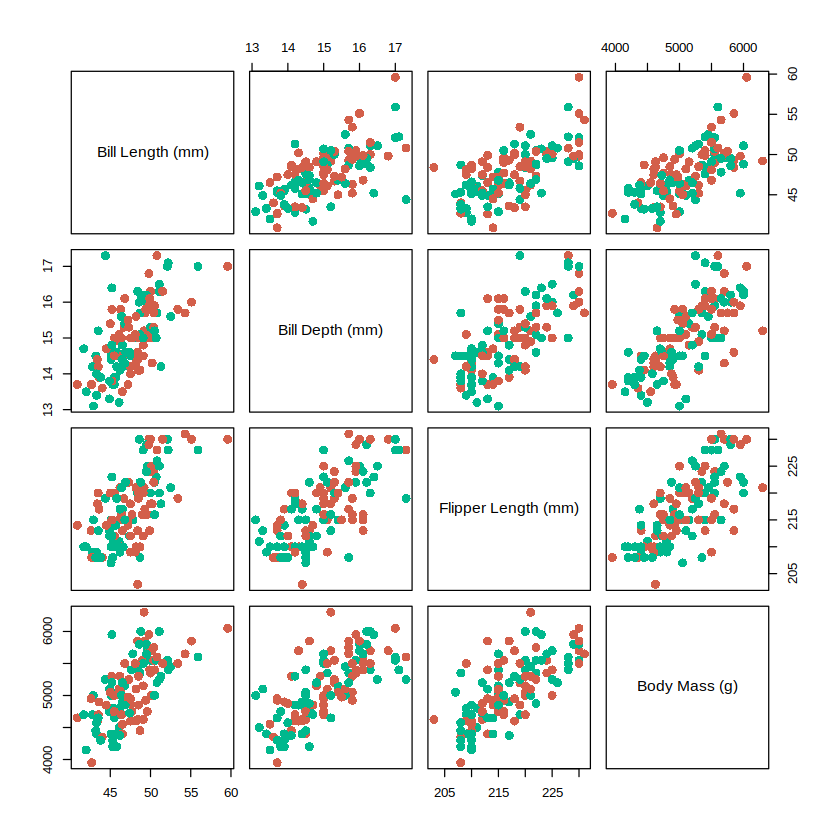

In [42]:
pairs(df[df$species == 'Gentoo', 3:6], 
      cex=1.5, 
      labels = c('Bill Length (mm)', 'Bill Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)'), 
      pch=16, 
      col = sex_color[df$sex])

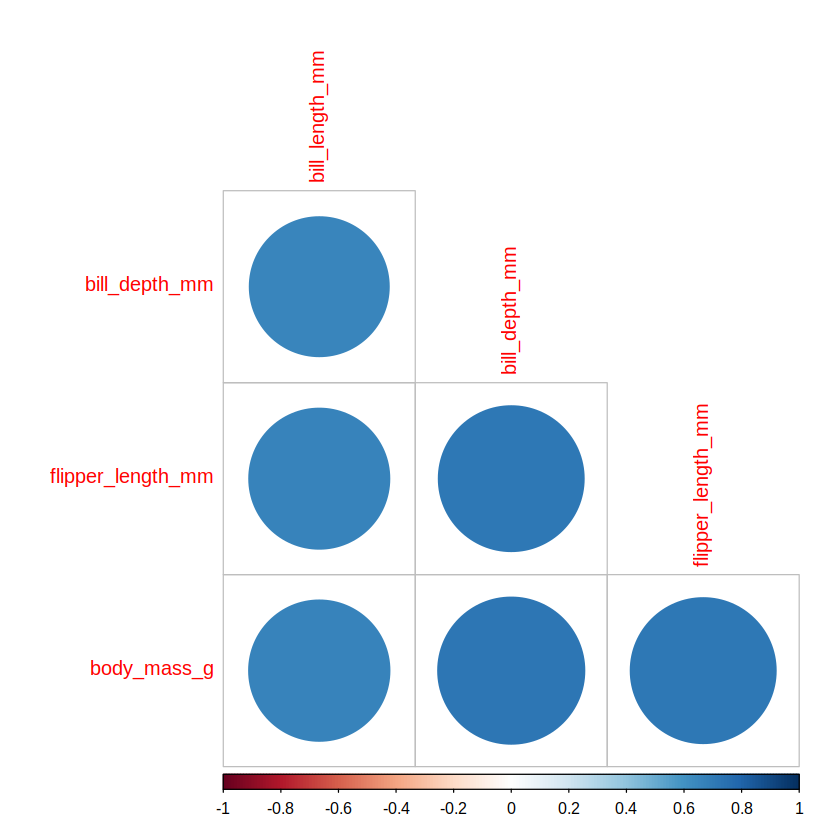

In [46]:
df_adelie.cor <- cor(df[df$species == 'Gentoo', 3:6])
df_adelie.test <- cor.mtest(df[df$species == 'Gentoo', 3:6])
gentoo.corrplot <- corrplot(df_adelie.cor, p.mat = df_adelie.test$p, insig = 'blank', , type = 'lower', diag = FALSE)

In [58]:
df_correlaciones <- adelie.corrplot$corrPos %>% mutate(species = 'Adelie')
df_correlaciones <- chinstrap.corrplot$corrPos %>% mutate(species = 'Chinstrap') %>% rbind(., df_correlaciones)
df_correlaciones <- gentoo.corrplot$corrPos %>% mutate(species = 'Gentoo') %>% rbind(., df_correlaciones)
df_correlaciones

xName,yName,x,y,corr,p.value,species
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
bill_length_mm,bill_depth_mm,1,3,0.6540233,7.336624e-16,Gentoo
bill_length_mm,flipper_length_mm,1,2,0.6642052,1.803166e-16,Gentoo
bill_length_mm,body_mass_g,1,1,0.6667302,1.262418e-16,Gentoo
bill_depth_mm,flipper_length_mm,2,2,0.7106422,1.398081e-19,Gentoo
bill_depth_mm,body_mass_g,2,1,0.7229672,1.639865e-20,Gentoo
flipper_length_mm,body_mass_g,3,1,0.7113053,1.249398e-19,Gentoo
bill_length_mm,bill_depth_mm,1,3,0.6535362,1.525539e-09,Chinstrap
bill_length_mm,flipper_length_mm,1,2,0.4716073,4.915785e-05,Chinstrap
bill_length_mm,body_mass_g,1,1,0.5136383,7.480492e-06,Chinstrap


In [61]:
#correlaciones fuertes
df_correlaciones[df_correlaciones$corr >= 0.7, ]

,xName,yName,x,y,corr,p.value,species
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
4,bill_depth_mm,flipper_length_mm,2,2,0.7106422,1.398081e-19,Gentoo
5,bill_depth_mm,body_mass_g,2,1,0.7229672,1.639865e-20,Gentoo
6,flipper_length_mm,body_mass_g,3,1,0.7113053,1.249398e-19,Gentoo


`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'



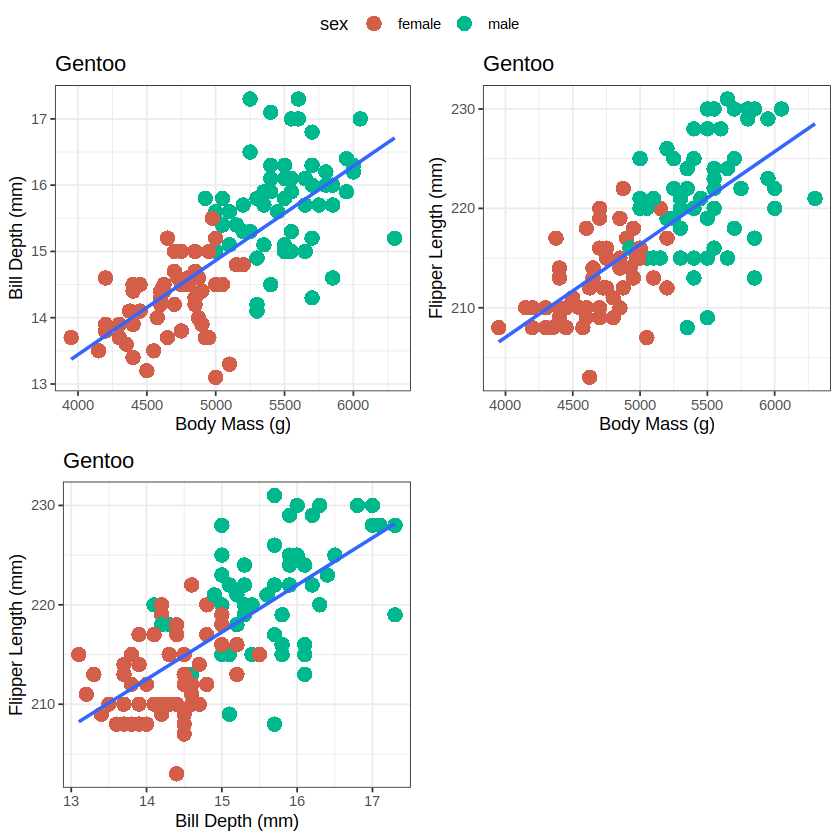

In [113]:
p1 <- ggplot(data = df[df$species == 'Gentoo', ], 
        aes(y = bill_depth_mm, x = body_mass_g)) +
        geom_point(size = 4, pch=16, aes(color = sex , shape = sex)) + 
        scale_color_manual(values = sex_color)+
        geom_smooth(method = 'lm', se = FALSE) +
        labs(  y = "Bill Depth (mm)",
               x = "Body Mass (g)") +
        ggtitle("Gentoo ") +
        theme_bw() +
        theme(legend.position = c(0.85, 0.2))

p2 <- ggplot(data = df[df$species == 'Gentoo', ], 
        aes(y = flipper_length_mm, x = body_mass_g)) +
        geom_point(size = 4, pch=16, aes(color = sex , shape = sex)) + 
        scale_color_manual(values = sex_color)+
        geom_smooth(method = 'lm', se = FALSE) +
        labs(  y = "Flipper Length (mm)",
               x = "Body Mass (g)") +
        ggtitle("Gentoo ") +
        theme_bw() +
        theme(legend.position = c(0.85, 0.2))

p3 <- ggplot(data = df[df$species == 'Gentoo', ], 
        aes(y = flipper_length_mm, x = bill_depth_mm)) +
        geom_point(size = 4, pch=16, aes(color = sex , shape = sex)) + 
        scale_color_manual(values = sex_color)+
        geom_smooth(method = 'lm', se = FALSE) +
        labs(  y = "Flipper Length (mm)",
               x = "Bill Depth (mm)") +
        ggtitle("Gentoo ") +
        theme_bw() +
        theme(legend.position = c(0.85, 0.2))

ggarrange(p1, p2, p3, NULL, 
          ncol = 2, nrow = 2, common.legend = TRUE, legend="top")

In [62]:
#correlacions moderadas
df_correlaciones[df_correlaciones$corr >= 0.5 & df_correlaciones$corr< 0.7, ]

,xName,yName,x,y,corr,p.value,species
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,bill_length_mm,bill_depth_mm,1,3,0.6540233,7.336624e-16,Gentoo
2,bill_length_mm,flipper_length_mm,1,2,0.6642052,1.803166e-16,Gentoo
3,bill_length_mm,body_mass_g,1,1,0.6667302,1.262418e-16,Gentoo
7,bill_length_mm,bill_depth_mm,1,3,0.6535362,1.525539e-09,Chinstrap
9,bill_length_mm,body_mass_g,1,1,0.5136383,7.480492e-06,Chinstrap
10,bill_depth_mm,flipper_length_mm,2,2,0.5801429,2.160279e-07,Chinstrap
11,bill_depth_mm,body_mass_g,2,1,0.6044983,4.794503e-08,Chinstrap
12,flipper_length_mm,body_mass_g,3,1,0.6415594,3.748130e-09,Chinstrap
15,bill_length_mm,body_mass_g,1,1,0.5442764,1.241918e-12,Adelie
